## Model Problem A: Gaussian Targets

Assuming that 
$$
    \mu_0 = N(0, C) \quad \mu = N(m, \tilde{C})
$$
and then we can write
$$
    \mu(dx) \propto \exp( - \Phi(x)) \mu_0(dx)
$$
where 
$$
    \Phi(x) = \frac{1}{2} \langle (\tilde{C}^{-1} + C^{-1})x, x \rangle  
    - \langle \tilde{C}^{-1} x , m \rangle.
$$

## Model Problem B: Find the Surface

We consider the statistical inversion problem of estimating $\mathbf{x} \in \mathbb{R}^n$ from data $z \in \mathbb{R}$ gathered according the measurement model:
$$
    z = f(\mathbf{x}) + \eta     \tag{MM1}
$$    
where
$$    
    \eta \sim N(0, \sigma^2) \text{ and } f: \mathbb{R}^n \to \mathbb{R}
    \text{ is the forward function. }
$$
Leaving aside the measurement noise $\eta$ we would like to recover the preimage $f^{-1}(z)$.  We constrain this set with Gaussian prior $\mu_0 \sim N(0, C)$ on $\mathbf{x}$. Then the posterior 'bayesian solution' $\mathbf{x}|z$ is the distribution:
$$
    \mu(d\mathbf{x}) \propto \exp\left( - \frac{1}{2 \sigma^2} ( f(\mathbf{x}) - z)^2 
    - \frac{1}{2} <C^{-1}\mathbf{x}, \mathbf{x}>\right) d\mathbf{x}.
    \tag{S1}
$$

## Model Problem C: Matrix Coefficents from Solutions

We next consider inverse problem of estimating the coefficents of an $n \times n$ anti-semetric matrix $A$ from data $\theta \in \mathbb{R}^n$ gathered according the measurement model:
$$
    z = \mathcal{O}(\theta(A)) + \eta \qquad \text{ where } \eta \sim N(0, \sigma^2)
    \tag{MM2}
$$
Here $\theta := \theta(A)$ is the solution of
$$
    (A + \kappa I)\theta = g
$$
and where $\mathcal{O}(\theta)$ defined by $\mathcal{O}: \mathbb{R}^n \to \mathbb{R}^m$ is a partial observation of $\theta$. Typically
$$
    \mathcal{O}((\theta_1, \ldots, \theta_n)) = (\theta_1,\ldots, \theta_m)
$$
Here the Bayesian posterior will take the form
$$
    \mu(dA) \propto \exp\left( - \frac{1}{2 \sigma^2} 
    | \mathcal{O}( (A +\kappa I)^{-1} g) - z|^2 
    - \frac{1}{2} <C^{-1}A, A>\right) dA.
    \tag{S1}
$$
which is a target in $d = n(n-1)/2$






In [48]:
%load_ext autoreload
%autoreload 2

#Set-up: Packages to Import and Untility Functions

#Core Numerical Packages for Paral
import MCMC_Sampliers_Testing as MCMCsmp
import Utilities as Utils

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag
import random
import math

#Input Output utils
import os
import pandas as pd

#Stats elements
#from scipy.stats import norm
from scipy.stats import chi2

#Plotting stuff
from matplotlib.patches import Ellipse

#Finished Message
import smtplib
from email.message import EmailMessage

from functools import partial
import multiprocessing as mp

def run_p_Sweep_Batches(ImpLists, q0Fn, TarDim, CovPrior, Pot, saveFileBase,tsComp,burnIn):
    for ImpList in ImpLists:
        curPList = [I[0] for I in ImpList]
        print("Running Blocks for: " + str(curPList))
        saveDictLocCur = saveFileBase + "data_dict_info_p_"
        for p in curPList:
           saveDictLocCur += str(p) + "_" 
        saveDictLocCur += ".npy"
        if __name__ == "__main__":
            par_sweep_dict = Utils.parameter_sweep_p_rho(ImpList, q0FN, TarDim, CovPrior, Pot, saveDictExt=True,
                                                           saveDictLoc = saveDictLocCur)

        #par_sweep_dictEx1 = np.load(saveDictLocCur, allow_pickle=True).item()

        Utils.parameter_sweep_p_rho_save_figures(par_sweep_dict, TarDim, tsComp,burnIn, saveFileBase)


print("Current cpu count:" + str(mp.cpu_count()))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current cpu count:24


In [ ]:
#Experiment A1
#Gaussian target (changing Covariance/mean on `low modes')

#Make Problem Information File
expId =  1
FileNmBase = "/home/neghadmin/Dropbox/MCMC_Runs/Large_p_study/Experiment_A/" + "Ex_ID_"+ str(expId) + "/"
os.makedirs(FileNmBase, exist_ok=True)


#Model dim
TarDimEx1 = 5
#Covariance algebraic decay
cov0 = 4
gam = 2
CovDiag_p = [cov0* (j**(-gam)) for j in list(range(1,TarDimEx1+1))]

CovPriorEx1 = Utils.mkDiagCov(CovDiag_p)
print("Prior Covariance:")
print(CovPriorEx1)

#Information for Gaussian Posterior
#Perturb dim
pertDimEx1 = 2
CovDiag_post = [CovDiag_p[1], CovDiag_p[0]] + CovDiag_p[pertDimEx1:]
CovPostEx1 = Utils.mkDiagCov(CovDiag_post)
meanPostEx1 = np.zeros(TarDimEx1)

print("Posterior Covariance:")
print(CovPostEx1)

probDataFile = FileNmBase + "Problem_Info.txt"
with open(probDataFile, 'w') as file:
    file.write("Target Type:  Model Problem A -- Gaussian Target \n")
    file.write("Target Dimension: " + str(TarDimEx1) + "\n")
    file.write("Prior Covariance: \n" + str(CovPriorEx1) + "\n")
    file.write("Perturbation Dimension: " + str(pertDimEx1) + "\n")
    file.write("Posterior Mean: " + str(meanPostEx1) + "\n")
    file.write("Posterior Covariance: \n" + str(CovPostEx1)+ "\n")

PriorCovInvEx1 = Utils.mkDiagCov([CovDiag_p[0]**(-1),CovDiag_p[1]**(-1)])
PostCovInvEx1 = Utils.mkDiagCov([CovDiag_post[0]**(-1),CovDiag_post[1]**(-1)])

PotEx1Pass = partial(Utils.PotGaussPert, TarDim=TarDimEx1, PertDim=pertDimEx1, PriorCovInv=PriorCovInvEx1, PostMean=meanPostEx1[0:pertDimEx1], PostCovInv=PostCovInvEx1, mode = "soft")


ImpList1 = [[5,50,50000,100,5000], [10,50,50000,100,5000], [20,10,5000,100,5000], [40,10,5000,100,5000]]
ImpList2 = [[80,50,50000,100,5000], [160,50,50000,100,5000]]
ImpList3 = [[320,50,50000,100,5000], [640,50,50000,100,5000]]
ImpList4 = [[1280,50,50000,100,5000]]

ImpLists = [ImpList1, ImpList2, ImpList3,ImpList4]
#FORMAT: [p,NumRho,NumSampsESS,numChainsESS, NumChainsgM]
#            -p: value to p to run study
#            -NumRho: 1/NumRho specfies the step size in rho over [0,1] for the study
#            -NumSampsESS: Length of the MCMC at each rho value to compute ESS/MSJD
#            -numChainsESS: Number of independent chains to compute ESS/MSJD
#            -NumChainsgM: Number of separate chain M= NumChainsgM to compute Var(\bar{g}_N^\rho)



q0FN = lambda nmICs: np.random.multivariate_normal(np.zeros(TarDimEx1), CovPostEx1, size=nmICs)


#run_p_Sweep_Batches(ImpLists, q0Fn, TarDim, CovPrior, Pot, saveFileBase,tsComp,burnIn

Utils.message_ntfy("RUNNING EXAMPLE A1")

run_p_Sweep_Batches(ImpLists, q0FN, TarDimEx1, CovPriorEx1, PotEx1Pass, FileNmBase,[0,1,4],1000)




Prior Covariance:
[[4.         0.         0.         0.         0.        ]
 [0.         1.         0.         0.         0.        ]
 [0.         0.         0.44444444 0.         0.        ]
 [0.         0.         0.         0.25       0.        ]
 [0.         0.         0.         0.         0.16      ]]
Posterior Covariance:
[[1.         0.         0.         0.         0.        ]
 [0.         4.         0.         0.         0.        ]
 [0.         0.         0.44444444 0.         0.        ]
 [0.         0.         0.         0.25       0.        ]
 [0.         0.         0.         0.         0.16      ]]
Running Blocks for: [5, 10, 20, 40]
Currently running: p=5
Delta rho: 0.02
Number of Samples per Chain to compute ESS/MSJD: 50000
Number of Independent Chain to compute ESS/MSJD: 100
N in bar{g}_N^rho = 1/N sum_{j =1}^N g(X_jrho): 100
Number of separate chain M to compute Var(bar{g}_Nrho): 5000
Total MCMC Runs Submitted: 147


Parallel MCMC Runs:   0%|          | 0/147 [00:00<?, ?it/s]

Total Run Time Was: 1:00:46.296481
Currently running: p=10
Delta rho: 0.02
Number of Samples per Chain to compute ESS/MSJD: 50000
Number of Independent Chain to compute ESS/MSJD: 100
N in bar{g}_N^rho = 1/N sum_{j =1}^N g(X_jrho): 100
Number of separate chain M to compute Var(bar{g}_Nrho): 5000
Total MCMC Runs Submitted: 294


Parallel MCMC Runs:   0%|          | 0/294 [00:00<?, ?it/s]

Total Run Time Was: 1:30:15.452918
Currently running: p=20
Delta rho: 0.1
Number of Samples per Chain to compute ESS/MSJD: 5000
Number of Independent Chain to compute ESS/MSJD: 100
N in bar{g}_N^rho = 1/N sum_{j =1}^N g(X_jrho): 100
Number of separate chain M to compute Var(bar{g}_Nrho): 5000
Total MCMC Runs Submitted: 321


...

Building Time Series Plots:   0%|          | 0/4 [00:00<?, ?it/s]

Running Blocks for: [80, 160]
Currently running: p=80
Delta rho: 0.02
Number of Samples per Chain to compute ESS/MSJD: 50000
Number of Independent Chain to compute ESS/MSJD: 100
N in bar{g}_N^rho = 1/N sum_{j =1}^N g(X_jrho): 100
Number of separate chain M to compute Var(bar{g}_Nrho): 5000
Total MCMC Runs Submitted: 147


Parallel MCMC Runs:   0%|          | 0/147 [00:00<?, ?it/s]

Total Run Time Was: 8:34:58.100746
Currently running: p=160
Delta rho: 0.02
Number of Samples per Chain to compute ESS/MSJD: 50000
Number of Independent Chain to compute ESS/MSJD: 100
N in bar{g}_N^rho = 1/N sum_{j =1}^N g(X_jrho): 100
Number of separate chain M to compute Var(bar{g}_Nrho): 5000
Total MCMC Runs Submitted: 294


Parallel MCMC Runs:   0%|          | 0/294 [00:00<?, ?it/s]

In [ ]:
#Experiment A2
#Gaussian target (changing Covariance/mean on `low modes')

#Make Problem Information File
expId =  2
FileNmBase = "/home/neghadmin/Dropbox/MCMC_Runs/Large_p_study/Experiment_A/" + "Ex_ID_"+ str(expId) + "/"
os.makedirs(FileNmBase, exist_ok=True)


#Model dim
TarDimEx1 = 10
#Covariance algebraic decay
cov0 = 4
gam = 2
CovDiag_p = [cov0* (j**(-gam)) for j in list(range(1,TarDimEx1+1))]

CovPriorEx1 = Utils.mkDiagCov(CovDiag_p)
print("Prior Covariance:")
print(CovPriorEx1)

#Information for Gaussian Posterior
#Perturb dim
pertDimEx1 = 2
CovDiag_post = [CovDiag_p[1], CovDiag_p[0]] + CovDiag_p[pertDimEx1:]
CovPostEx1 = Utils.mkDiagCov(CovDiag_post)
meanPostEx1 = np.zeros(TarDimEx1)

print("Posterior Covariance:")
print(CovPostEx1)

probDataFile = FileNmBase + "Problem_Info.txt"
with open(probDataFile, 'w') as file:
    file.write("Target Type:  Model Problem A -- Gaussian Target \n")
    file.write("Target Dimension: " + str(TarDimEx1) + "\n")
    file.write("Prior Covariance: \n" + str(CovPriorEx1) + "\n")
    file.write("Perturbation Dimension: " + str(pertDimEx1) + "\n")
    file.write("Posterior Mean: " + str(meanPostEx1) + "\n")
    file.write("Posterior Covariance: \n" + str(CovPostEx1)+ "\n")

PriorCovInvEx1 = Utils.mkDiagCov([CovDiag_p[0]**(-1),CovDiag_p[1]**(-1)])
PostCovInvEx1 = Utils.mkDiagCov([CovDiag_post[0]**(-1),CovDiag_post[1]**(-1)])

PotEx1Pass = partial(Utils.PotGaussPert, TarDim=TarDimEx1, PertDim=pertDimEx1, PriorCovInv=PriorCovInvEx1, PostMean=meanPostEx1[0:pertDimEx1], PostCovInv=PostCovInvEx1, mode = "soft")


ImpList1 = [[5,50,50000,100,5000], [10,50,50000,100,5000], [20,10,5000,100,5000], [40,10,5000,100,5000]]
ImpList2 = [[80,50,50000,100,5000], [160,50,50000,100,5000]]
ImpList3 = [[320,50,50000,100,5000], [640,50,50000,100,5000]]
ImpList4 = [[1280,50,50000,100,5000]]

ImpLists = [ImpList1, ImpList2, ImpList3,ImpList4]
#FORMAT: [p,NumRho,NumSampsESS,numChainsESS, NumChainsgM]
#            -p: value to p to run study
#            -NumRho: 1/NumRho specfies the step size in rho over [0,1] for the study
#            -NumSampsESS: Length of the MCMC at each rho value to compute ESS/MSJD
#            -numChainsESS: Number of independent chains to compute ESS/MSJD
#            -NumChainsgM: Number of separate chain M= NumChainsgM to compute Var(\bar{g}_N^\rho)



q0FN = lambda nmICs: np.random.multivariate_normal(np.zeros(TarDimEx1), CovPostEx1, size=nmICs)


#run_p_Sweep_Batches(ImpLists, q0Fn, TarDim, CovPrior, Pot, saveFileBase,tsComp,burnIn

Utils.message_ntfy("RUNNING EXAMPLE A2")

run_p_Sweep_Batches(ImpLists, q0FN, TarDimEx1, CovPriorEx1, PotEx1Pass, FileNmBase,[0,1,4],1000)

In [3]:
saveDictLocCur = FileNmBase + "data_dict_info.npy"

if __name__ == "__main__":
    par_sweep_dictEx1 = Utils.parameter_sweep_p_rho(ImpList, q0FN, TarDimEx1, CovPriorEx1, PotEx1Pass, saveDictExt=True,
                                                   saveDictLoc = saveDictLocCur)



par_sweep_dictEx1 = np.load(saveDictLocCur, allow_pickle=True).item()

Utils.parameter_sweep_p_rho_save_figures(par_sweep_dictEx1 , TarDimEx1, [0,1,4],1000, FileNmBase)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Building ESS Plots:   0%|          | 0/2 [00:00<?, ?it/s]

Building MSJD Plots:   0%|          | 0/2 [00:00<?, ?it/s]

Building Plots Var(g_N) for different g_N:   0%|          | 0/2 [00:00<?, ?it/s]

Building Time Series Plots:   0%|          | 0/2 [00:00<?, ?it/s]

In [23]:
%load_ext autoreload
%autoreload 2

#Core Numerical Packages for Paral
#import MCMC_Sampliers_Testing as MCMCsmp
#import Utilities as Utils


#Experiment B1: Set-up

#We consider a target of the type Model Problem B, [MM1] where
#    f(x,y) = y(x-a)^r 

#The problem parameters are:
expId = 1 #Experiment ID

NumParmsExB1 = 2
zExB1 = 6
aExB1 = .3
rExB1 = 1
sigExB1 = 1
CovExB1 = np.diag([3,2])

#Make Loglikehood function with lambda workaround
#using PotEx1(X,sig, a,r,z)
#print(inspect.signature(MCMCsmp.PotEx1))

PotExB1Pass = partial(Utils.PotExB1, sig=sigExB1, a= aExB1, r=rExB1, z=zExB1,  mode="soft")


#Make Problem Information File
FileNmBase = "Data/Large_p_study/Experiment_B/" + "Ex_ID_"+ str(expId) + "/"
os.makedirs(FileNmBase, exist_ok=True)

probDataFile = FileNmBase + "Problem_Info.txt"
fFnStr = "y (x - " + str(aExB1) + ")^" + str(rExB1) 

with open(probDataFile, 'w') as file:
    file.write("Target Type:  Model Problem B \n")
    file.write("Model Dim: " + str(NumParmsExB1) + "\n")
    file.write("Forward Map:  f(x,y) = " + fFnStr + "\n")
    file.write("z: " + str(zExB1) + "\n")
    file.write("sig: " + str(sigExB1)+ "\n")
    file.write("Prior Cov: " + "\n" + str(CovExB1))

#parallel_MCMC_Runs_ESS(chainLn,numChain,MCMCmeth,MCMCmethArgs, q0gen, burn_In):
#MpCN(q0,dim,Cov,rho,Pot,NProps,L)

chainLn = 10000
numChain = 100
MC_meth = MCMCsmp.MpCN
warmrho = 0.2
warmp = 1000
q0gen = q0FN = lambda: np.random.multivariate_normal(np.zeros(NumParmsExB1), CovExB1)
MC_arg = [NumParmsExB1,CovExB1,warmrho,PotExB1Pass,warmp]
samps, ESS = Utils.parallel_MCMC_Runs_ESS(chainLn,numChain,MC_meth,MC_arg,q0gen, 500)

ESS_N_min = ESS.min()/(chainLn*numChain)
print(ESS_N_min)
thin_smp = 5*int(1/ESS_N_min)
print(thin)
thinned_samps = samps[::thin]

#Core Numerical Packages for Paral
import MCMC_Sampliers_Testing as MCMCsmp
import Utilities as Utils


chainLn = 10000
numChain = 100
q0genFull = lambda:random.choice(thinned_samps)

#parallel_MCMC_Runs(chainLn,numChain,MCMCmeth,MCMCmethArgs, q0gen, burn_In, thin)
FinalSampsExB1 = Utils.parallel_MCMC_Runs(chainLn,numChain,MC_meth,MC_arg,q0genFull, 500,thin)

#makeHistGrid(R, dr, sampList, NumParams,saveLoc, C=None, beta=0.95, hidePlt = True):

R =5
dr=.1

histFileNm = FileNmBase + "Baseline_Histogram.png"
Utils.makeHistGrid(R, dr, FinalSampsExB1, NumParmsExB1,histFileNm, C=CovExB1, beta=0.95, hidePlt = True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Total MCMC Runs: 100


Parallel MCMC Runs:   0%|          | 0/100 [00:00<?, ?it/s]

0.7138582533588371
5
Total MCMC Runs: 100


Parallel MCMC Runs:   0%|          | 0/100 [00:00<?, ?it/s]

In [31]:
#Experiment B2: Set-up

#We consider a target of the type Model Problem B, [MM1] where
#    f(x) = x* C^{-1} x

#The problem parameters are:
expId = 2 #Experiment ID

NumParmsExB2 = 2
cov0 = 4
gam = 2
CovDiag_p = [cov0* (j**(-gam)) for j in list(range(1,NumParmsExB2+1))]
CovInvDiag_p = [cov0**(-1) * (j**(gam)) for j in list(range(1,NumParmsExB2+1))]

sigExB2 = .5

#Compute zExB2 so that \mu({x | x^* C^{-1} x \leq zBxB2\}) = prob_below
prob_below = .95
zExB2 = chi2.ppf(prob_below, df=NumParmsExB2)  

CovPriorExB2 = Utils.mkDiagCov(CovDiag_p)
CovPriorInvExB2 = Utils.mkDiagCov(CovInvDiag_p) 


#Make Loglikehood function with lambda workaround
#using PotEx1(X,sig, a,r,z)
#print(inspect.signature(MCMCsmp.PotEx1))

#PotExB2(X, sig, CovInv, zdata)
PotExB2Pass = partial(Utils.PotExB2, sig=sigExB2, CovInv = CovPriorInvExB2,  zdata = zExB2, mode="soft")


#Make Problem Information File
FileNmBase = "Data/Large_p_study/Experiment_B/" + "Ex_ID_"+ str(expId) + "/"
os.makedirs(FileNmBase, exist_ok=True)

probDataFile = FileNmBase + "Problem_Info.txt"
fFnStrB2 = "x* C^{-1} x"

with open(probDataFile, 'w') as file:
    file.write("Target Type:  Model Problem B \n")
    file.write("Model Dim: " + str(NumParmsExB2) + "\n")
    file.write("Forward Map:  f(x) = " + fFnStrB2 + "\n")
    file.write("z: " + str(zExB2) + "\n")
    file.write("sig: " + str(sigExB2)+ "\n")
    file.write("Prior Cov: " + "\n" + str(CovPriorExB2))

#parallel_MCMC_Runs_ESS(chainLn,numChain,MCMCmeth,MCMCmethArgs, q0gen, burn_In):
#MpCN(q0,dim,Cov,rho,Pot,NProps,L)

chainLn = 10000
numChain = 100
MC_meth = MCMCsmp.MpCN
warmrho = 0.5
warmp = 100
q0gen = q0FN = lambda: np.random.multivariate_normal(np.zeros(NumParmsExB2), CovPriorExB2)
MC_arg = [NumParmsExB2,CovPriorExB2,warmrho,PotExB2Pass,warmp]
sampsExB2, ESS = Utils.parallel_MCMC_Runs_ESS(chainLn,numChain,MC_meth,MC_arg,q0gen, 500)

ESS_N_min = ESS.min()/(chainLn*numChain)
print(ESS_N_min)
thin_smp = 5*int(1/ESS_N_min)
print(thin)

R =5
dr=.1

histFileNm = FileNmBase + "Baseline_Histogram.png"
Utils.makeHistGrid(R, dr, sampsExB2, NumParmsExB2,histFileNm, C=CovPriorExB2, beta=0.95, hidePlt = True)

Total MCMC Runs: 100


Parallel MCMC Runs:   0%|          | 0/100 [00:00<?, ?it/s]

0.22465243687142786
5


In [32]:
#Experiment B3

#We consider a target of the type Model Problem B, [MM1] where
#    f(x) = x* C^{-1} x

#The problem parameters are:
expId = 3 #Experiment ID

NumParmsExB2 = 10
cov0 = 4
gam = 2
CovDiag_p = [cov0* (j**(-gam)) for j in list(range(1,NumParmsExB2+1))]
CovInvDiag_p = [cov0**(-1) * (j**(gam)) for j in list(range(1,NumParmsExB2+1))]

sigExB2 = .5

#Compute zExB2 so that \mu({x | x^* C^{-1} x \leq zBxB2\}) = prob_below
prob_below = .95
zExB2 = chi2.ppf(prob_below, df=NumParmsExB2)  

CovPriorExB2 = Utils.mkDiagCov(CovDiag_p)
CovPriorInvExB2 = Utils.mkDiagCov(CovInvDiag_p) 


#Make Loglikehood function with lambda workaround
#using PotEx1(X,sig, a,r,z)
#print(inspect.signature(MCMCsmp.PotEx1))

#PotExB2(X, sig, CovInv, zdata)
PotExB2Pass = partial(Utils.PotExB2, sig=sigExB2, CovInv = CovPriorInvExB2,  zdata = zExB2, mode="soft")


#Make Problem Information File
FileNmBase = "Data/Large_p_study/Experiment_B/" + "Ex_ID_"+ str(expId) + "/"
os.makedirs(FileNmBase, exist_ok=True)

probDataFile = FileNmBase + "Problem_Info.txt"
fFnStrB2 = "x* C^{-1} x"

with open(probDataFile, 'w') as file:
    file.write("Target Type:  Model Problem B \n")
    file.write("Model Dim: " + str(NumParmsExB2) + "\n")
    file.write("Forward Map:  f(x) = " + fFnStrB2 + "\n")
    file.write("z: " + str(zExB2) + "\n")
    file.write("sig: " + str(sigExB2)+ "\n")
    file.write("Prior Cov: " + "\n" + str(CovPriorExB2))

#parallel_MCMC_Runs_ESS(chainLn,numChain,MCMCmeth,MCMCmethArgs, q0gen, burn_In):
#MpCN(q0,dim,Cov,rho,Pot,NProps,L)

chainLn = 10000
numChain = 100
MC_meth = MCMCsmp.MpCN
warmrho = 0.5
warmp = 100
q0gen = q0FN = lambda: np.random.multivariate_normal(np.zeros(NumParmsExB2), CovPriorExB2)
MC_arg = [NumParmsExB2,CovPriorExB2,warmrho,PotExB2Pass,warmp]
sampsExB2, ESS = Utils.parallel_MCMC_Runs_ESS(chainLn,numChain,MC_meth,MC_arg,q0gen, 500)

ESS_N_min = ESS.min()/(chainLn*numChain)
print(ESS_N_min)
thin_smp = 5*int(1/ESS_N_min)
print(thin)

R =5
dr=.1

histFileNm = FileNmBase + "Baseline_Histogram.png"
Utils.makeHistGrid(R, dr, sampsExB2, NumParmsExB2,histFileNm, C=CovPriorExB2, beta=0.95, hidePlt = True)

Total MCMC Runs: 100


Parallel MCMC Runs:   0%|          | 0/100 [00:00<?, ?it/s]

0.24986136151851635
5


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Total MCMC Runs: 100


Parallel MCMC Runs:   0%|          | 0/100 [00:00<?, ?it/s]

0.10435779785293064
5


AttributeError: 'numpy._ArrayFunctionDispatcher' object has no attribute 'ppf'

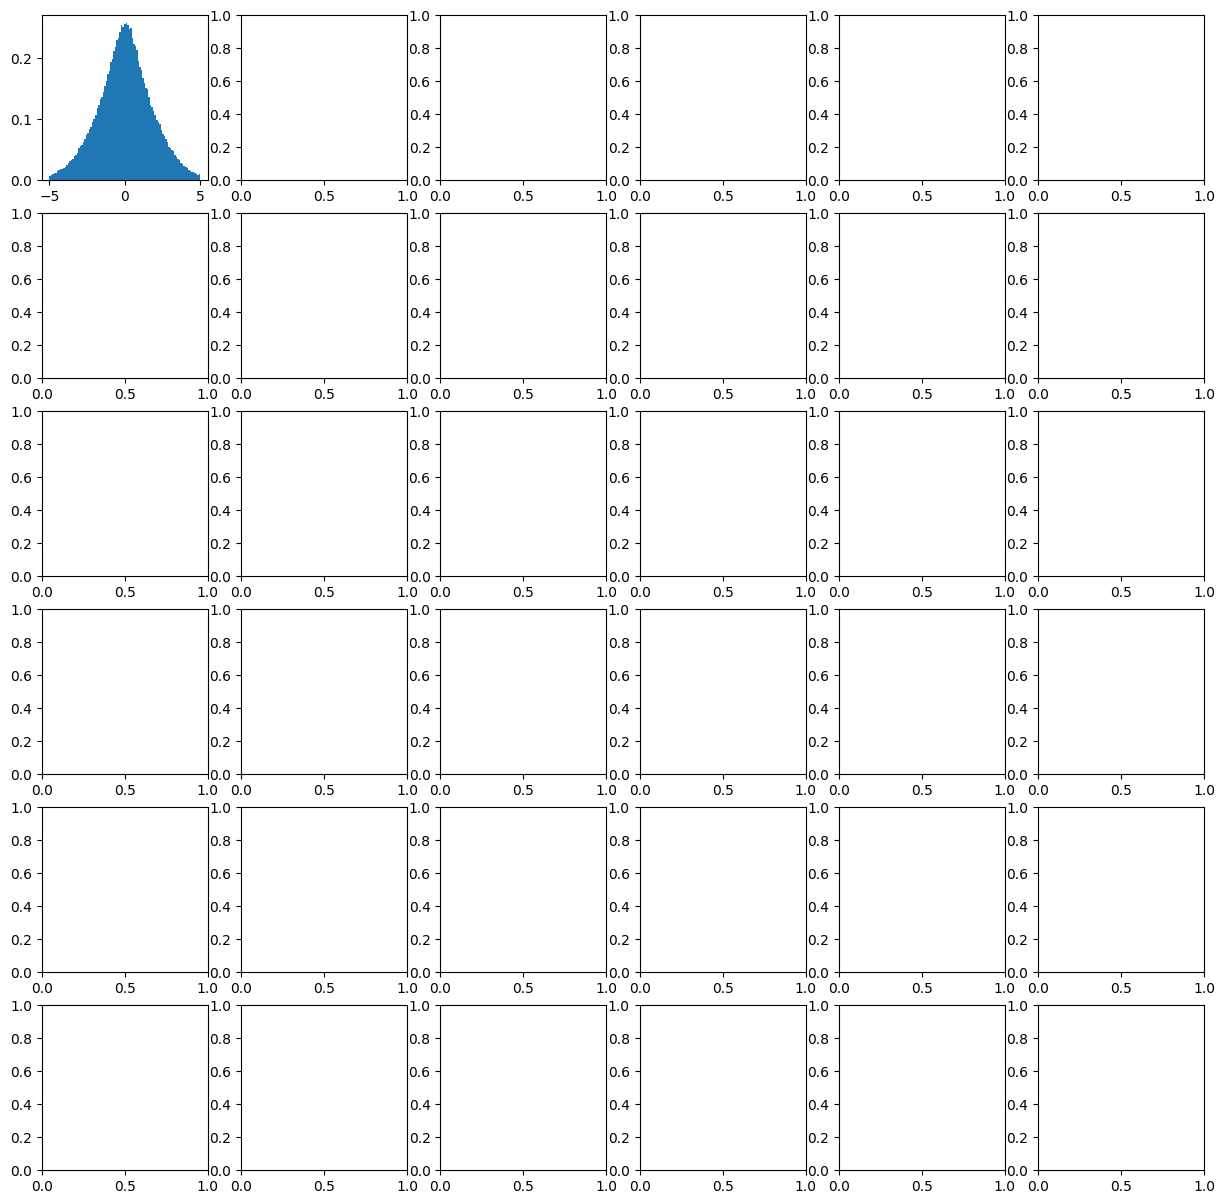

In [41]:
%load_ext autoreload
%autoreload 2

#Core Numerical Packages for Paral
import MCMC_Sampliers_Testing as MCMCsmp
import Utilities as Utils


#Experiment C1: Set-up

#This experiment is based on Model Problem C
#We use precisely the example appearing in refer [1]

#We Specifying Problem Parameters as follows
#Model dimension and parameter space size are
ModDmEx3= 4
NumParmsEx3 = int(ModDmEx3*(ModDmEx3 -1)/2)


expId = 1 #Experiment ID
 
gvecEx3 = np.array([.1,0,5,2])
sigEx3 = 2
zEx3 = np.array([4.601,18.021,0,0])
dataDimEx3 = 2
kapEx3= .05

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A
cov0 = 5
gam = 1.5
CovEx3 = np.diag([cov0* (j**(-gam)) for j in list(range(1,NumParmsEx3+1))])

#Make Problem Information File
FileNmBase = "Data/Large_p_study/Experiment_C/" + "Ex_ID_"+ str(expId) + "/"
os.makedirs(FileNmBase, exist_ok=True)

probDataFile = FileNmBase + "Problem_Info.txt"
with open(probDataFile, 'w') as file:
    file.write("Target Type:  Model Problem B \n")
    file.write("Model Dim: " + str(NumParmsEx3) + "\n")
    file.write("g: " + str(gvecEx3) + "\n")
    file.write("z: " + str(zEx3[0:2]) + "\n")
    file.write("sig: " + str(sigEx3)+ "\n")
    file.write("kappa: " + str(kapEx3)+ "\n")
    file.write("Prior Cov: " + "\n" + str(CovEx3))

#Make Loglikehood function with lambda workaround
#using PotExAD(a, gvec, sig, ModDm, z, kap, dataDim, mode = None):
#print(inspect.signature(MCMCsmp.PotExAD))


PotEx3Pass = partial(Utils.PotExAD, gvec=gvecEx3, sig=sigEx3, ModDm=ModDmEx3, z=zEx3, kap=kapEx3, dataDim=dataDimEx3, mode = "soft")


chainLn = 10000
numChain = 100
MC_meth = MCMCsmp.MpCN
warmrho = 0.5
warmp = 100
q0gen = q0FN = lambda: np.random.multivariate_normal(np.zeros(NumParmsEx3), CovEx3)
MC_arg = [NumParmsEx3,CovEx3,warmrho,PotEx3Pass,warmp]
sampsExC1, ESS = Utils.parallel_MCMC_Runs_ESS(chainLn,numChain,MC_meth,MC_arg,q0gen, 500)

ESS_N_min = ESS.min()/(chainLn*numChain)
print(ESS_N_min)
thin_smp = 5*int(1/ESS_N_min)
print(thin)

R =5
dr=.1

histFileNm = FileNmBase + "Baseline_Histogram.png"
Utils.makeHistGrid(R, dr, sampsExC1, NumParmsEx3,histFileNm, C=CovEx3, beta=0.95, hidePlt = True)
